## Notebook 04 - What drives price per m² in Bordeaux?
Question: how much of the price per m² is explained by surface, rooms, property type, location and year?
**Method:** load the data from PostgreSQL, explore each factor with medians, then fit a simple regression to compare their effects.

### Step 1 - Load Bordeaux data from PostgreSQL
Same connection as notebook 03. The password is typed at runtime (`getpass`), so it is never stored in the notebook or committed to Git.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from getpass import getpass
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

engine = create_engine(URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password=getpass("PostgreSQL password: "),
    host="localhost",
    port=5432,
    database="dvf_bordeaux",
))

bdx = pd.read_sql("SELECT * FROM sales_clean WHERE nom_commune = 'Bordeaux'", engine)
print(bdx.shape)
bdx.head()

(23419, 14)


,id_mutation,date_mutation,valeur_fonciere,code_postal,code_commune,nom_commune,type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,longitude,latitude,price_per_m2,year
0,2021-502606,2021-01-05,214380.0,33000,33063,Bordeaux,Appartement,38.0,2.0,NaN,-0.570149,44.832857,5641.578947,2021
1,2021-502608,2021-01-08,153000.0,33800,33063,Bordeaux,Appartement,30.0,2.0,NaN,-0.565518,44.832603,5100.000000,2021
2,2021-502610,2021-01-04,650000.0,33000,33063,Bordeaux,Maison,120.0,3.0,171.0,-0.601241,44.829355,5416.666667,2021
3,2021-502612,2021-01-05,228000.0,33200,33063,Bordeaux,Appartement,66.0,3.0,NaN,-0.631002,44.846707,3454.545455,2021
4,2021-502613,2021-01-06,300000.0,33000,33063,Bordeaux,Maison,63.0,3.0,81.0,-0.596852,44.837450,4761.904762,2021


### Step 2 - Surface vs price per m²
Bin surface into size classes and compare medians. Small flats usually cost more per m² than large ones.

                           count       median
type_local  surface_class                    
Appartement <25             2093  5325.000000
            25-40           3446  4750.000000
            40-60           4822  4380.000000
            60-80           4118  3960.988231
            80-120          2541  4073.684211
            120+             580  4669.078014
Maison      <25               14  5770.833333
            25-40            124  6263.888889
            40-60            653  5851.063830
            60-80           1140  5183.841270
            80-120          1971  5087.719298
            120+            1917  5078.780488


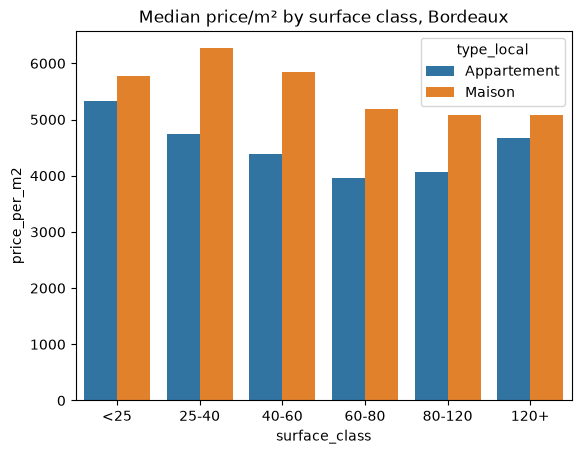

In [5]:
bdx["surface_class"] = pd.cut(bdx["surface_reelle_bati"], [0, 25, 40, 60, 80, 120, 500],
                              labels=["<25", "25-40", "40-60", "60-80", "80-120", "120+"])
t = bdx.groupby(["type_local", "surface_class"], observed=True)["price_per_m2"].agg(["count", "median"])
print(t)
sns.barplot(data=bdx, x="surface_class", y="price_per_m2", hue="type_local", estimator=np.median, errorbar=None)
plt.title("Median price/m² by surface class, Bordeaux")
plt.show()

### Step 2 - Results
Apartments: median price/m² falls from 5,325 € (<25 m²) to 3,961 € (60-80 m²), then rises again for large units (4,074 for 80-120 m², 4,669 for 120+ m²). Houses fall from about 6,264 (25-40 m²) to about 5,080 (80 m² and above) and are above apartments in every class.
**Observation:** small units are priced higher per m². The U shape for apartments is not explained yet (hypothesis: large apartments are rare and premium).
**Caveat:** houses under 25 m² have only 14 sales. House prices include the land.

### Step 3 - Rooms vs price per m²

In [6]:
bdx["rooms"] = bdx["nombre_pieces_principales"].clip(upper=6)
print(bdx.groupby(["type_local", "rooms"])["price_per_m2"].agg(["count", "median"]))

                   count       median
type_local  rooms                    
Appartement 0.0        7  5470.588235
            1.0     3776  4991.109422
            2.0     5857  4562.500000
            3.0     4787  4166.666667
            4.0     2343  3909.638554
            5.0      684  3569.153776
            6.0      146  4603.120879
Maison      0.0        1  7058.823529
            1.0       68  5884.210526
            2.0      502  5536.507937
            3.0     1322  5205.976190
            4.0     1698  5090.796460
            5.0     1159  5145.663265
            6.0     1069  5144.772727


### Step 3 - Results
Apartments: median falls with the number of rooms, from 4,991 (1 room) to 3,569 (5 rooms); 6+ rooms goes back up to 4,603 (146 sales). Houses are flat at about 5,100-5,200 from 3 rooms.
**Caveat:** rooms and surface are correlated, so these effects overlap. The regression separates them.

In [ ]:
### Step 4 - Location: postal code
Bordeaux is split by postal code (33000, 33100, 33200, 33300, 33800), a rough proxy for neighborhoods.

In [7]:
print(bdx.groupby("code_postal")["price_per_m2"].agg(["count", "median"]).sort_values("median", ascending=False))

             count       median
code_postal                    
33000        10500  5000.000000
33800         3678  4477.272727
33100         1301  4366.197183
33200         4216  4166.666667
33300         3724  4116.963064


### Step 4 - Results
Median price/m² by postal code: 33000: 5,000 (10,500 sales), 33800: 4,477, 33100: 4,366, 33200: 4,167, 33300: 4,117. The centre is about 21% above the cheapest area.
**Caveat:** the property-type mix differs by area, which can inflate a medians gap. Controlled in Step 5.

In [ ]:
### Step 5 - Regression: how much does each factor explain?
Model: `log(price_per_m2) ~ log(surface) + rooms + house + postal code + year` (linear regression, scikit-learn).
**Why log:** coefficients become percentage effects, and the skewed price distribution is tamed.
**Importance of each factor:** I remove one factor at a time and measure how much R² drops.
**Limitation:** R² is measured on the same data used to fit the model, and the model has no floor, view, condition or distance to the centre. It describes associations, not causes.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

m = bdx[bdx["nombre_pieces_principales"] >= 1].copy()
m["log_price"] = np.log(m["price_per_m2"])
m["log_surface"] = np.log(m["surface_reelle_bati"])
m["rooms"] = m["nombre_pieces_principales"].clip(upper=6)
m["house"] = (m["type_local"] == "Maison").astype(float)
m["code_postal"] = m["code_postal"].astype(str)

X = pd.get_dummies(m[["log_surface", "rooms", "house", "code_postal", "year"]],
                   columns=["code_postal", "year"], drop_first=True, dtype=float)
y = m["log_price"]

model = LinearRegression().fit(X, y)
full_r2 = r2_score(y, model.predict(X))
print(f"Full model R2: {full_r2:.3f}  (n={len(m)})\n")

groups = {
    "surface": ["log_surface"],
    "rooms": ["rooms"],
    "type (house)": ["house"],
    "postal code": [c for c in X.columns if c.startswith("code_postal_")],
    "year": [c for c in X.columns if c.startswith("year_")],
}
rows = []
for name, cols in groups.items():
    reduced = X.drop(columns=cols)
    r2 = r2_score(y, LinearRegression().fit(reduced, y).predict(reduced))
    rows.append({"factor": name, "R2 lost if removed": round(full_r2 - r2, 3)})
print(pd.DataFrame(rows).sort_values("R2 lost if removed", ascending=False).to_string(index=False))

coef = pd.Series(model.coef_, index=X.columns)
effects = ((np.exp(coef) - 1) * 100).round(1)
print("\nEffect in % on price/m² (dummies: vs the reference category; rooms: per extra room):")
print(effects.drop("log_surface").to_string())
print(f"\n+10% surface -> price/m² changes by {((1.10 ** coef['log_surface']) - 1) * 100:.1f}%")

Full model R2: 0.178  (n=23411)

      factor  R2 lost if removed
type (house)               0.084
 postal code               0.063
        year               0.021
     surface               0.015
       rooms               0.000

Effect in % on price/m² (dummies: vs the reference category; rooms: per extra room):
rooms                -0.1
house                30.2
code_postal_33100   -14.1
code_postal_33200   -15.4
code_postal_33300   -16.0
code_postal_33800   -15.3
year_2022             1.3
year_2023            -1.7
year_2024            -8.8
year_2025            -9.9

+10% surface -> price/m² changes by -1.4%


### Step 5 - Results
Full model R² = 0.178 (n = 23,411): the factors available in DVF explain about 18% of the variation in price/m² in Bordeaux.
Importance (R² lost if removed): type 0.084, postal code 0.063, year 0.021, surface 0.015, rooms 0.000.
Effects on price/m²: house +30.2% vs apartment; postal codes 33100/33200/33300/33800 are 14-16% below 33000 (centre); 2024 -8.8% and 2025 -9.9% vs 2021; +10% surface -> -1.4%.
**Reading:** property type and location matter most. Rooms add nothing once surface is controlled (surface and rooms correlate at 0.90).
**Cross-check:** the 2025 effect (-9.9%) is consistent with the raw median fall (-10.3%), so the decline is not a change in sales mix.
**Limitations:** low R² (no floor, condition, view, exact street); in-sample R²; the "drop one" measure is unreliable for correlated factors; the house effect includes land; associations, not causes.

### Step 6 - Correlation heatmap
Spearman rank correlations between price/m², surface, rooms, land area and year (Spearman is robust to outliers).

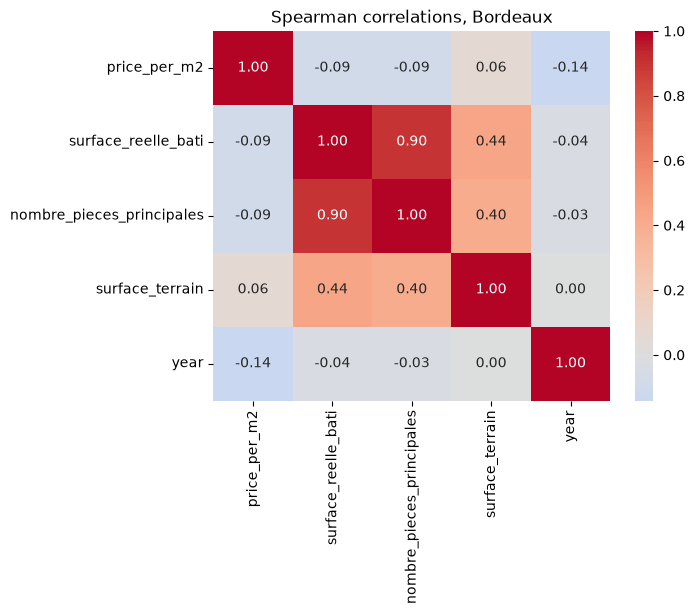

In [9]:
cols = ["price_per_m2", "surface_reelle_bati", "nombre_pieces_principales", "surface_terrain", "year"]
sns.heatmap(bdx[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlations, Bordeaux")
plt.show()

### Step 6 - Results
Price/m² has weak Spearman correlations with every numeric variable (surface -0.09, rooms -0.09, land +0.06, year -0.14). Surface and rooms are strongly correlated (0.90).
**Reading:** no single numeric variable drives price/m²; type and location do (Step 5). The year correlation reflects the post-2022 decline.
**Limitation:** Spearman misses non-monotonic patterns such as the U shape of apartments by surface.

### Step 7 - Does distance to the centre improve the model?
Add `dist_center_km` (straight-line distance to Place de la Bourse, computed from latitude/longitude) and compare R² on a held-out 20% test set.
**Why:** postal code is coarse; distance is a finer location measure. The train/test split gives an honest R² instead of an in-sample one.
**Rooms are dropped** because they add nothing once surface is included.

In [10]:
from sklearn.model_selection import train_test_split

lat0, lon0 = 44.8412, -0.5698   # Place de la Bourse (approximate)
m2 = m.dropna(subset=["latitude", "longitude"]).copy()
dy = (m2["latitude"] - lat0) * 111.0
dx = (m2["longitude"] - lon0) * 111.0 * np.cos(np.radians(lat0))
m2["dist_center_km"] = np.sqrt(dx**2 + dy**2)

def test_r2(df, features, cat_cols):
    X = pd.get_dummies(df[features + cat_cols], columns=cat_cols, drop_first=True, dtype=float)
    X_tr, X_te, y_tr, y_te = train_test_split(X, df["log_price"], test_size=0.2, random_state=42)
    return r2_score(y_te, LinearRegression().fit(X_tr, y_tr).predict(X_te))

print("Test R2, without distance:", round(test_r2(m2, ["log_surface", "house"], ["code_postal", "year"]), 3))
print("Test R2, with distance:   ", round(test_r2(m2, ["log_surface", "house", "dist_center_km"], ["code_postal", "year"]), 3))
print(m2["dist_center_km"].describe().round(2))

Test R2, without distance: 0.177
Test R2, with distance:    0.252
count    23285.00
mean         2.20
std          1.19
min          0.07
25%          1.33
50%          2.00
75%          2.91
max          5.79
Name: dist_center_km, dtype: float64


### Step 7 - Results
Held-out test R² (20% of the data): 0.177 without distance, 0.252 with distance to Place de la Bourse (+0.075).
Distances range from 0.07 to 5.79 km (median 2.0 km), so coordinates are consistent with Bordeaux.
**Reading:** distance to the centre is a finer location measure than postal code and explains substantially more. The in-sample R² (0.178) was close to the test R² (0.177), so the first model was not overfitting.
**Limitations:** straight-line distance ignores the river, tram lines and neighborhood character; the centre point is approximate; most variation (about 75%) is still unexplained; associations, not causes.

### Step 8 - How much does price/m² fall with distance?
Fit the model with distance on all data and read the coefficient. Then compare median price/m² by distance band as a plain-language check.

In [11]:
X = pd.get_dummies(m2[["log_surface", "house", "dist_center_km", "code_postal", "year"]],
                   columns=["code_postal", "year"], drop_first=True, dtype=float)
mod = LinearRegression().fit(X, m2["log_price"])
per_km = (np.exp(mod.coef_[list(X.columns).index("dist_center_km")]) - 1) * 100
print(f"Each extra km from the centre -> price/m² changes by {per_km:.1f}%\n")

m2["dist_band"] = pd.cut(m2["dist_center_km"], [0, 1, 2, 3, 4, 6], labels=["0-1", "1-2", "2-3", "3-4", "4+"])
print(m2.groupby(["type_local", "dist_band"], observed=True)["price_per_m2"].agg(["count", "median"]).round(0))

Each extra km from the centre -> price/m² changes by -10.0%

                       count  median
type_local  dist_band               
Appartement 0-1         3473  5098.0
            1-2         6427  4773.0
            2-3         3891  4207.0
            3-4         2103  3788.0
            4+          1609  3435.0
Maison      0-1           70  4646.0
            1-2         1659  5375.0
            2-3         2235  5233.0
            3-4          968  5321.0
            4+           850  4608.0
